In [28]:
import time
import tracemalloc                          # Buat ukur MEMORI
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics

In [29]:
#Pembersihan dan Penggabungan
df = pd.read_csv('../data/komdigi_hoaks.csv')

df['teks'] = df['title'].fillna('') + ' ' + df['excerpt'].fillna('')
df = df[df['teks'].str.strip() != ''].reset_index(drop=True)

print(f"Total data bersih siap klasterisasi: {len(df)} baris")
df[['title', 'teks']].head()

Total data bersih siap klasterisasi: 4176 baris


,title,teks
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,[HOAKS] Tautan Pencairan BSU September 2026 Se...
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...


In [30]:
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['teks'])

X_euclidean = X

print("Bentuk matriks data:", X_euclidean.shape)

Bentuk matriks data: (4176, 1000)


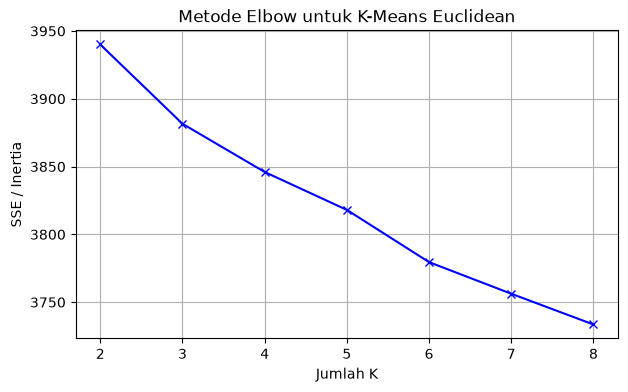

In [31]:
sse = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_euclidean)
    sse.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, sse, 'bx-')
plt.xlabel('Jumlah K')
plt.ylabel('SSE / Inertia')
plt.title('Metode Elbow untuk K-Means Euclidean')
plt.grid(True)
plt.show()

In [32]:
# Mulai pelacakan memori & waktu
tracemalloc.start()
waktu_mulai = time.time()

k_terpilih = 6
kmeans_euclidean = KMeans(n_clusters=k_terpilih, random_state=42, n_init=10)
df['cluster_kmeans_euclidean'] = kmeans_euclidean.fit_predict(X_euclidean)

waktu_selesai = time.time()
mem_sekarang, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

hasil_jumlah_klaster = k_terpilih
hasil_waktu = waktu_selesai - waktu_mulai
hasil_memori_mb = mem_puncak / (1024 * 1024)
hasil_silhouette = metrics.silhouette_score(X_euclidean, df['cluster_kmeans_euclidean'], metric='manhattan')

print("=" * 45)
print("HASIL PENGUJIAN: K-MEANS JARAK EUCLIDEAN")
print("=" * 45)
print(f"1. Jumlah Klaster   : {hasil_jumlah_klaster}")
print(f"2. Waktu Eksekusi    : {hasil_waktu:.4f} detik")
print(f"3. Silhouette Score : {hasil_silhouette:.4f} (metrik euclidean)")
print(f"4. Penggunaan Memori: {hasil_memori_mb:.2f} MB")
print("=" * 45)

HASIL PENGUJIAN: K-MEANS JARAK EUCLIDEAN
1. Jumlah Klaster   : 6
2. Waktu Eksekusi    : 0.1743 detik
3. Silhouette Score : 0.0011 (metrik euclidean)
4. Penggunaan Memori: 1.72 MB


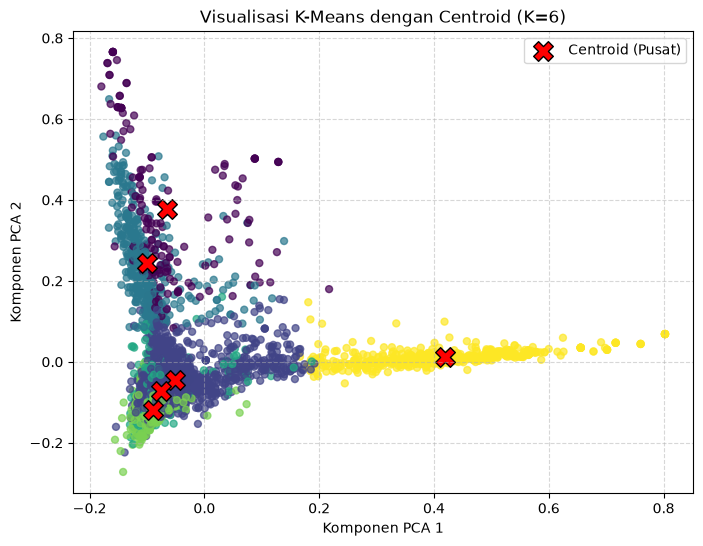

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_euclidean.toarray())

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['pca1'],
    df['pca2'],
    c=df['cluster_kmeans_euclidean'],
    cmap='viridis',
    s=25,
    alpha=0.7,
)

centers_pca = pca.transform(kmeans_euclidean.cluster_centers_)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker='X',
    s=200,
    color='red',
    edgecolors='black',
    label='Centroid (Pusat)',
)

plt.title(f'Visualisasi K-Means dengan Centroid (K={k_terpilih})')
plt.xlabel('Komponen PCA 1')
plt.ylabel('Komponen PCA 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [34]:
order_centroids = kmeans_euclidean.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()

print("Kata Kunci Dominan Tiap Klaster:")
for i in range(k_terpilih):
    top_terms = [terms[ind] for ind in order_centroids[i, :7]]
    print(f"Kluster {i}: {', '.join(top_terms)}")

Kata Kunci Dominan Tiap Klaster:
Kluster 0: lowongan, kerja, pt, pekerjaan, tautan, hoaks, pendaftaran
Kluster 1: hoaks, di, video, indonesia, dan, yang, pada
Kluster 2: tautan, pendaftaran, hoaks, 2026, untuk, dan, telegram
Kluster 3: bantuan, dana, video, ai, artificial, intelligence, hoaks
Kluster 4: presiden, prabowo, hoaks, jokowi, subianto, gibran, dan
Kluster 5: akun, mengatasnamakan, whatsapp, kabupaten, bupati, hoaks, facebook
